# Classification

In [61]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

KORS_PATH    = Path('../data/original/Forts_IRAF_SAT_Kors.xlsx')
RAK_PATH     = Path('../data/original/Forts_IRAF_SAT_RAK.xlsx')
FEATURES_DIR = Path('../data/processed/features')
SELECTED_DIR = FEATURES_DIR / 'combined/per_video'
OUT_DIR      = Path('../data/processed/classification')
OUT_DIR.mkdir(parents=True, exist_ok=True)

PHASE_MAP = {
    'iraf_utgångsposition':  'selected_features_init.csv',
    'iraf_rörelsestart':     'selected_features_start.csv',
    'iraf_rörelseutförande': 'selected_features_execution.csv',
    'iraf_total':            'selected_features_total.csv',
}

## Load IRAF Scores

In [62]:
def parse_iraf_per_video(xl, sheet_name, fp_videos=None):
    raw = xl.parse(sheet_name, header=None)
    col0 = raw.iloc[:, 0].astype(str)
    film_rows = raw.index[col0.str.contains('Film Nr', na=False)].tolist()
    film_rows.append(len(raw))
    records = []
    phase_weight_records = []
    for i, start in enumerate(film_rows[:-1]):
        video = col0.iloc[start].split(': ')[1].strip().zfill(3)
        block = raw.iloc[start:film_rows[i+1]]
        bc0 = block.iloc[:, 0].astype(str)
        up_idx = bc0[bc0.str.strip() == 'Utgångsposition'].index
        rs_idx = bc0[bc0.str.strip() == 'Rörelsestart'].index
        ru_idx = bc0[bc0.str.strip() == 'Rörelseutförande'].index
        if not (len(up_idx) and len(rs_idx) and len(ru_idx)):
            continue
        up_i, rs_i, ru_i = up_idx[0], rs_idx[0], ru_idx[0]
        end_i = film_rows[i+1]
        for phase, p_i in [('utgångsposition', up_i), ('rörelsestart', rs_i), ('rörelseutförande', ru_i)]:
            phase_weight_records.append({'video': video, 'phase': phase, 'phase_weight': raw.iloc[p_i, 1]})
        for phase, p_start, p_end in [
            ('utgångsposition', up_i+1, rs_i),
            ('rörelsestart',    rs_i+1, ru_i),
            ('rörelseutförande', ru_i+1, end_i)
        ]:
            for _, r in raw.iloc[p_start:p_end].iterrows():
                weight = pd.to_numeric(r[1], errors='coerce')
                avvik  = pd.to_numeric(r[3], errors='coerce')
                if pd.notna(weight) and pd.notna(avvik) and str(r[5]).strip().lower() != 'x':
                    records.append({'video': video, 'phase': phase,
                                    'weight': weight, 'avvikelse': float(avvik)})
    return pd.DataFrame(records), pd.DataFrame(phase_weight_records)

kors_xl = pd.ExcelFile(KORS_PATH)
rak_xl  = pd.ExcelFile(RAK_PATH)
kors_df, kors_pw = parse_iraf_per_video(kors_xl, 'Sittande till stående')
rak_df,  rak_pw  = parse_iraf_per_video(rak_xl,  'Sittande till stående')
iraf_raw = pd.concat([kors_df, rak_df], ignore_index=True)
iraf_raw = iraf_raw.assign(w=iraf_raw['avvikelse'] * iraf_raw['weight'])

phase_weights = pd.concat([kors_pw, rak_pw]).groupby('phase')['phase_weight'].mean().to_dict()

iraf_pv = iraf_raw.groupby(['video', 'phase']).apply(
    lambda g: g['w'].sum() / g['weight'].sum()
).unstack().reset_index()
iraf_pv.columns.name = None
iraf_pv.columns = ['video'] + [f'iraf_{c}' for c in iraf_pv.columns[1:]]

total_w = sum(phase_weights.values())
iraf_pv['iraf_total'] = sum(iraf_pv[f'iraf_{p}'] * w for p, w in phase_weights.items()) / total_w

iraf_pv

,video,iraf_rörelsestart,iraf_rörelseutförande,iraf_utgångsposition,iraf_total
0,028,2.0,0.6875,1.047619,1.314732
1,030,0.0,0.0000,0.052632,0.019737
2,045,2.0,0.9375,1.142857,1.412946
3,047,0.0,0.3125,0.619048,0.310268
4,059,2.0,0.9375,1.238095,1.448661
5,061,0.0,0.1250,0.263158,0.129934
6,074,2.0,0.9375,1.285714,1.466518
7,076,0.0,0.5625,0.095238,0.176339
8,091,1.0,0.6875,1.571429,1.136161
9,093,1.0,0.3125,0.421053,0.611020


## Transform target to binary labels
Target: IRAF score 
- 0 (no deviation): score ≤ 0.5  
- 1 (deviation): score > 0.6  
- Values in (0.5, 0.6] are excluded (gray zone)

In [63]:
def to_binary(score):
    if score <= 0.5:
        return 0
    elif score > 0.6:
        return 1
    return np.nan

iraf_bin = iraf_pv.copy()
for col in ['iraf_utgångsposition', 'iraf_rörelsestart', 'iraf_rörelseutförande', 'iraf_total']:
    iraf_bin[col] = iraf_bin[col].apply(to_binary)

iraf_bin['video'] = iraf_bin['video'].astype(str).str[-3:]
print(iraf_bin.to_string())

  video  iraf_rörelsestart  iraf_rörelseutförande  iraf_utgångsposition  iraf_total
0   028                  1                    1.0                     1           1
1   030                  0                    0.0                     0           0
2   045                  1                    1.0                     1           1
3   047                  0                    0.0                     1           0
4   059                  1                    1.0                     1           1
5   061                  0                    0.0                     0           0
6   074                  1                    1.0                     1           1
7   076                  0                    NaN                     0           0
8   091                  1                    1.0                     1           1
9   093                  1                    0.0                     0           1


## Load features per phase

In [64]:
pose_all = (
    pd.read_csv(FEATURES_DIR / 'utgångsposition.csv')
    .merge(pd.read_csv(FEATURES_DIR / 'rörelsestart.csv'),     on='video')
    .merge(pd.read_csv(FEATURES_DIR / 'rörelseutförande.csv'), on='video')
)
molab_all = (
    pd.read_csv(FEATURES_DIR / 'molab_utgångsposition.csv')
    .merge(pd.read_csv(FEATURES_DIR / 'molab_rörelsestart.csv'),     on='video')
    .merge(pd.read_csv(FEATURES_DIR / 'molab_rörelseutförande.csv'), on='video')
)

pose_all['video']  = pose_all['video'].astype(str).str.zfill(3)
molab_all['video'] = molab_all['video'].astype(str).str.zfill(3)

pose_cols  = {c: f'pose_{c}'  for c in pose_all.columns  if c != 'video'}
molab_cols = {c: f'molab_{c}' for c in molab_all.columns if c != 'video'}
pose_all   = pose_all.rename(columns=pose_cols)
molab_all  = molab_all.rename(columns=molab_cols)

iraf_bin['video'] = iraf_bin['video'].astype(str).str[-3:]

phase_dfs = {}
for target, fname in PHASE_MAP.items():
    sel         = pd.read_csv(SELECTED_DIR / fname)
    pose_feats  = [f'pose_{f}'  for f in sel[sel['source'] == 'Pose']['feature']]
    molab_feats = [f'molab_{f}' for f in sel[sel['source'] == 'MoLab']['feature']]
    short       = target.replace('iraf_', '')
    pose_df     = pose_all[['video'] + pose_feats]
    molab_df    = molab_all[['video'] + molab_feats]
    phase_dfs[short] = {
        'pose':     pose_df,
        'molab':    molab_df,
        'combined': pose_df.merge(molab_df, on='video'),
        'y':        iraf_bin[['video', target]].dropna(subset=[target]),
    }

for phase, sources in phase_dfs.items():
    print(f"\n{phase}:")
    for source, val in sources.items():
        if source == 'y':
            labels = val.iloc[:, 1].astype(int).tolist()
            print(f"  y: {labels}")
        else:
            print(f"  {source}: {val.shape}  {val.columns[1:].tolist()}")



utgångsposition:
  pose: (10, 6)  ['pose_initial_trunk_angle', 'pose_mean_trunk_angle', 'pose_forb_delta_trunk_flexion', 'pose_delta_trunk_flexion', 'pose_forb_rms_trunk_acceleration']
  molab: (10, 6)  ['molab_delta_pelvis_tilt', 'molab_peak_pelvis_gyro', 'molab_forb_peak_pelvis_gyro', 'molab_mean_L_hip_flexion', 'molab_rms_pelvis_acc']
  combined: (10, 11)  ['pose_initial_trunk_angle', 'pose_mean_trunk_angle', 'pose_forb_delta_trunk_flexion', 'pose_delta_trunk_flexion', 'pose_forb_rms_trunk_acceleration', 'molab_delta_pelvis_tilt', 'molab_peak_pelvis_gyro', 'molab_forb_peak_pelvis_gyro', 'molab_mean_L_hip_flexion', 'molab_rms_pelvis_acc']
  y: [1, 0, 1, 1, 1, 0, 1, 0, 1, 0]

rörelsestart:
  pose: (10, 6)  ['pose_mean_head_trunk_angle', 'pose_trunk_hip_correlation', 'pose_initial_trunk_angle', 'pose_mean_trunk_angle', 'pose_forb_delta_trunk_flexion']
  molab: (10, 6)  ['molab_peak_pelvis_gyro', 'molab_forb_peak_pelvis_gyro', 'molab_max_pelvis_tilt', 'molab_delta_pelvis_tilt', 'molab_

## Classification: LOOCV

### Models: 
- **Logistic Regression**
- **Random Forest**
- **XGBoost**  


In [65]:
MODELS = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=30, max_depth=2, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=30, max_depth=2, learning_rate=0.1,
        eval_metric='logloss', random_state=42, verbosity=0
    ),
}

FEATURE_SETS = ['pose', 'molab', 'combined']
MODEL_ORDER  = list(MODELS.keys())
TARGET_COL   = 'iraf_'

loo = LeaveOneOut()
loocv_results = []

for phase, data in phase_dfs.items():
    target  = TARGET_COL + phase
    y_df    = data['y']
    videos  = y_df['video'].values
    y_all   = y_df[target].values.astype(int)
    for fs in FEATURE_SETS:
        merged = data[fs].merge(y_df[['video']], on='video')
        X      = merged.drop(columns='video').values
        for model_name, model in MODELS.items():
            y_true, y_pred, y_prob, vid_out = [], [], [], []
            for train_idx, test_idx in loo.split(X):
                X_train, X_test = X[train_idx], X[test_idx]
                y_train = y_all[train_idx]
                if len(np.unique(y_train)) < 2:
                    continue
                scaler  = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test  = scaler.transform(X_test)
                m = clone(model)
                m.fit(X_train, y_train)
                y_true.append(y_all[test_idx][0])
                y_pred.append(m.predict(X_test)[0])
                prob    = m.predict_proba(X_test)[0]
                pos_idx = list(m.classes_).index(1) if 1 in m.classes_ else 0
                y_prob.append(prob[pos_idx])
                vid_out.append(videos[test_idx][0])
            loocv_results.append({
                'phase':       phase,
                'model':       model_name,
                'feature_set': fs,
                'videos':      vid_out,
                'y_true':      y_true,
                'y_pred':      y_pred,
                'y_prob':      y_prob,
            })

print(f'Completed: {len(loocv_results)} models trained')


Completed: 36 models trained


## Evaluation

In [66]:
rows = []
for r in loocv_results:
    yt, yp, ypr = r['y_true'], r['y_pred'], r['y_prob']
    n_classes = len(set(yt))
    rows.append({
        'phase':       r['phase'],
        'model':       r['model'],
        'feature_set': r['feature_set'],
        'Accuracy':    accuracy_score(yt, yp),
        'F1':          f1_score(yt, yp, zero_division=0),
        'Precision':   precision_score(yt, yp, zero_division=0),
        'Recall':      recall_score(yt, yp, zero_division=0),
        'AUC':         roc_auc_score(yt, ypr) if n_classes > 1 else np.nan,
    })

eval_df = pd.DataFrame(rows)
eval_df.to_csv(OUT_DIR / 'classification_results.csv', index=False)

METRICS = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC']

for phase in eval_df['phase'].unique():
    print(f"\nPhase: {phase}")
    sub   = eval_df[eval_df['phase'] == phase].copy()
    table = sub.pivot_table(index='model', columns='feature_set', values=METRICS).round(3)
    table.columns = [f'{metric}_{fs}' for metric, fs in table.columns]
    print(table.to_string())
    print()



Phase: utgångsposition
                    AUC_combined  AUC_molab  AUC_pose  Accuracy_combined  Accuracy_molab  Accuracy_pose  F1_combined  F1_molab  F1_pose  Precision_combined  Precision_molab  Precision_pose  Recall_combined  Recall_molab  Recall_pose
model                                                                                                                                                                                                                                   
LogisticRegression         0.833      0.833     0.792                0.8             0.8            0.7        0.833     0.833    0.769               0.833            0.833           0.714            0.833         0.833        0.833
RandomForest               0.875      0.875     0.792                0.8             0.8            0.8        0.833     0.833    0.833               0.833            0.833           0.833            0.833         0.833        0.833
XGBoost                    0.000      0.000 

**Rörelseutförande** is the easiest phase to classify: Logistic Regression and Random Forest both achieve perfect scores (Accuracy=1.0, AUC=1.0) using Pose, MoLab, and Combined features.

**Rörelsestart and Total**: Logistic Regression leads with Accuracy=0.9 and Precision=1.0, which means no false positives.

**XGBoost performs poorly**: With only 9 training samples in LOOCV, the model overfits and predicts a single class (AUC = 0.0), making it unsuitable for this dataset size.

**Combined features offer no clear benefit**: Pose alone performs nearly as well as the Combined model, indicating minimal added value from MoLab.

## McNemar test: compare models pairwise

In [67]:
mcnemar_rows = []

model_pairs = [
    ('LogisticRegression', 'RandomForest'),
    ('LogisticRegression', 'XGBoost'),
    ('RandomForest',       'XGBoost'),
]

for phase in eval_df['phase'].unique():
    for fs in FEATURE_SETS:
        for m1, m2 in model_pairs:
            r1 = next(r for r in loocv_results
                      if r['phase'] == phase and r['model'] == m1 and r['feature_set'] == fs)
            r2 = next(r for r in loocv_results
                      if r['phase'] == phase and r['model'] == m2 and r['feature_set'] == fs)
            yt = np.array(r1['y_true'])
            p1 = np.array(r1['y_pred'])
            p2 = np.array(r2['y_pred'])
            b = np.sum((p1 == yt) & (p2 != yt))
            c = np.sum((p1 != yt) & (p2 == yt))
            table = [[np.sum((p1 == yt) & (p2 == yt)), b],
                     [c, np.sum((p1 != yt) & (p2 != yt))]]
            result = mcnemar(table, exact=True)
            mcnemar_rows.append({
                'phase':       phase,
                'feature_set': fs,
                'model_1':     m1,
                'model_2':     m2,
                'b':           b,
                'c':           c,
                'p_value':     result.pvalue,
                'significant': result.pvalue < 0.05,
            })

mcnemar_df = pd.DataFrame(mcnemar_rows)
mcnemar_df.to_csv(OUT_DIR / 'mcnemar_results.csv', index=False)

print(mcnemar_df[['phase','feature_set','model_1','model_2','p_value','significant']].to_string(index=False))


           phase feature_set            model_1      model_2  p_value  significant
 utgångsposition        pose LogisticRegression RandomForest  1.00000        False
 utgångsposition        pose LogisticRegression      XGBoost  1.00000        False
 utgångsposition        pose       RandomForest      XGBoost  0.62500        False
 utgångsposition       molab LogisticRegression RandomForest  1.00000        False
 utgångsposition       molab LogisticRegression      XGBoost  0.62500        False
 utgångsposition       molab       RandomForest      XGBoost  0.62500        False
 utgångsposition    combined LogisticRegression RandomForest  1.00000        False
 utgångsposition    combined LogisticRegression      XGBoost  0.62500        False
 utgångsposition    combined       RandomForest      XGBoost  0.62500        False
    rörelsestart        pose LogisticRegression RandomForest  1.00000        False
    rörelsestart        pose LogisticRegression      XGBoost  0.37500        False
    

**Rörelseutförande is the only phase with significant differences.**  
For the **Pose** and **Combined** feature sets:

- **LR vs XGBoost → p = 0.031**
- **RF vs XGBoost → p = 0.031**

These results indicate that **Logistic Regression (LR) and Random Forest (RF) perform significantly better than XGBoost in this phase**.

**No significant difference was found between LR and RF in any phase**, suggesting that these two models produce **similar prediction performance and error patterns** across the dataset.

## Visualisation: metrics per phase

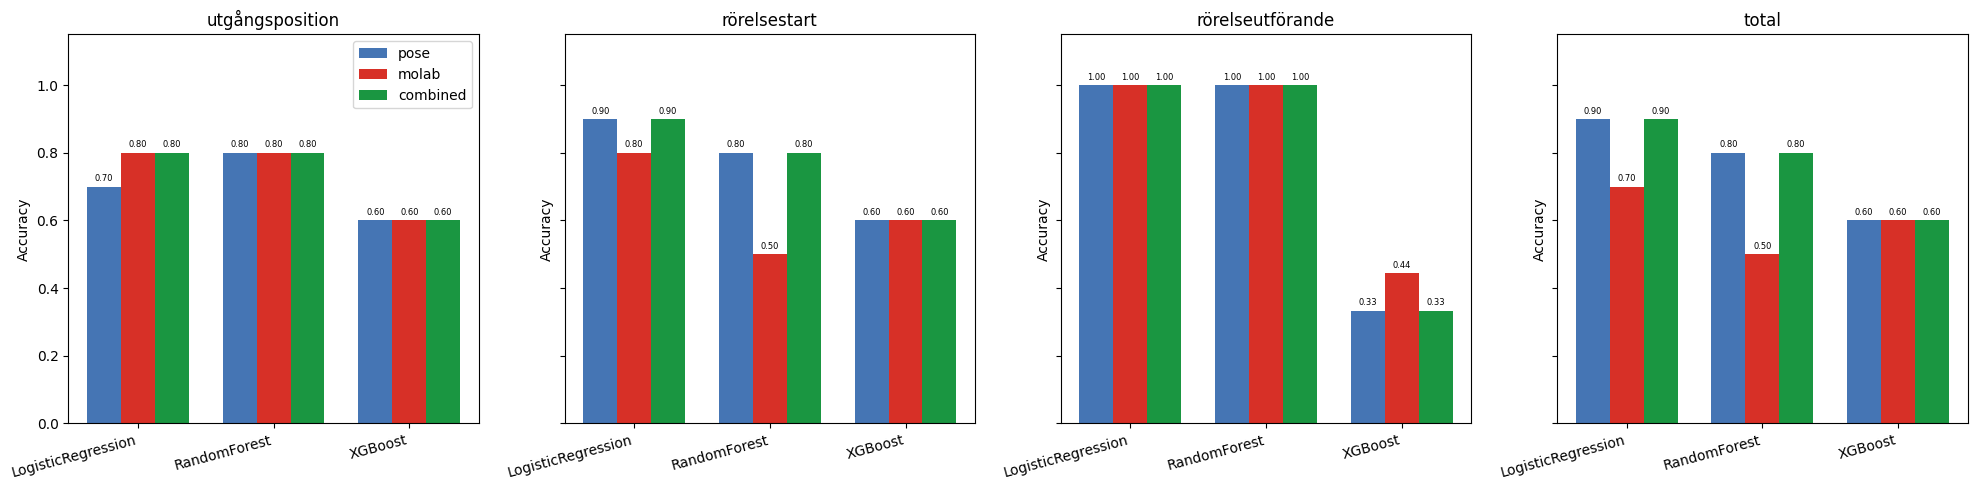

Saved: classification_accuracy_bar.png


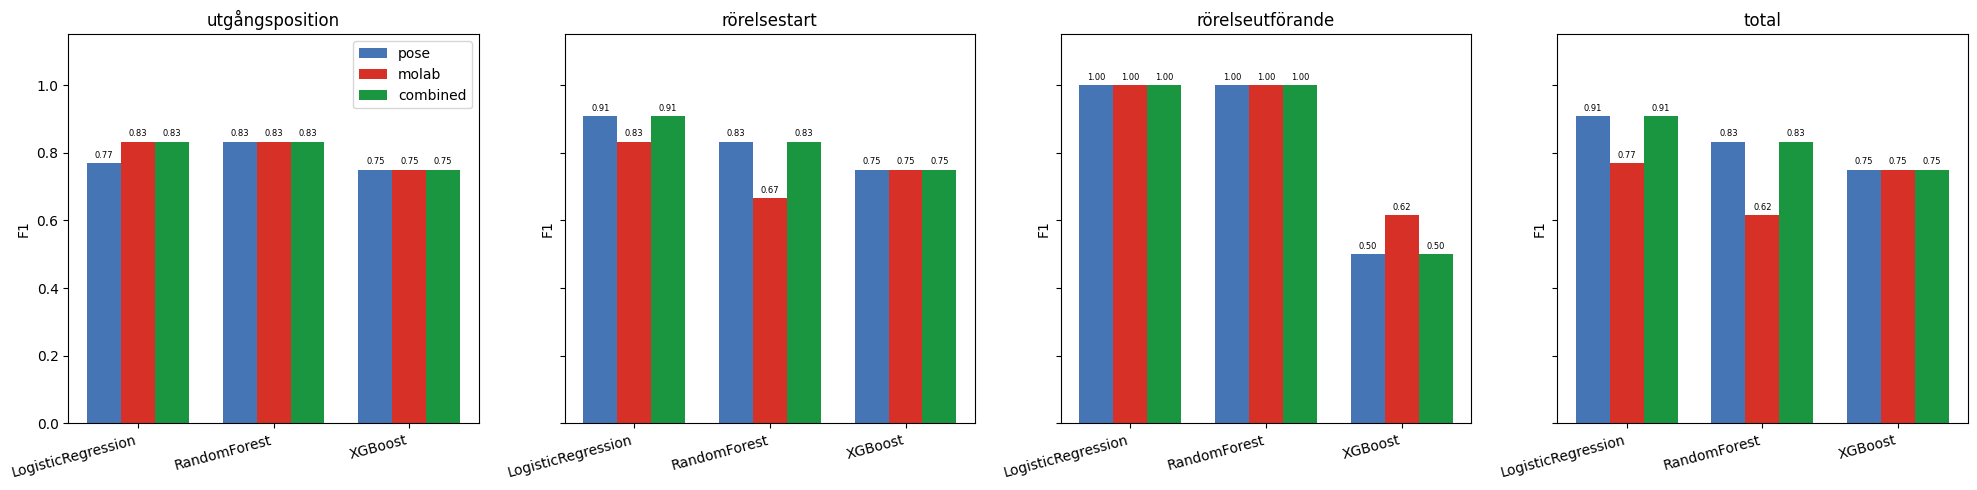

Saved: classification_f1_bar.png


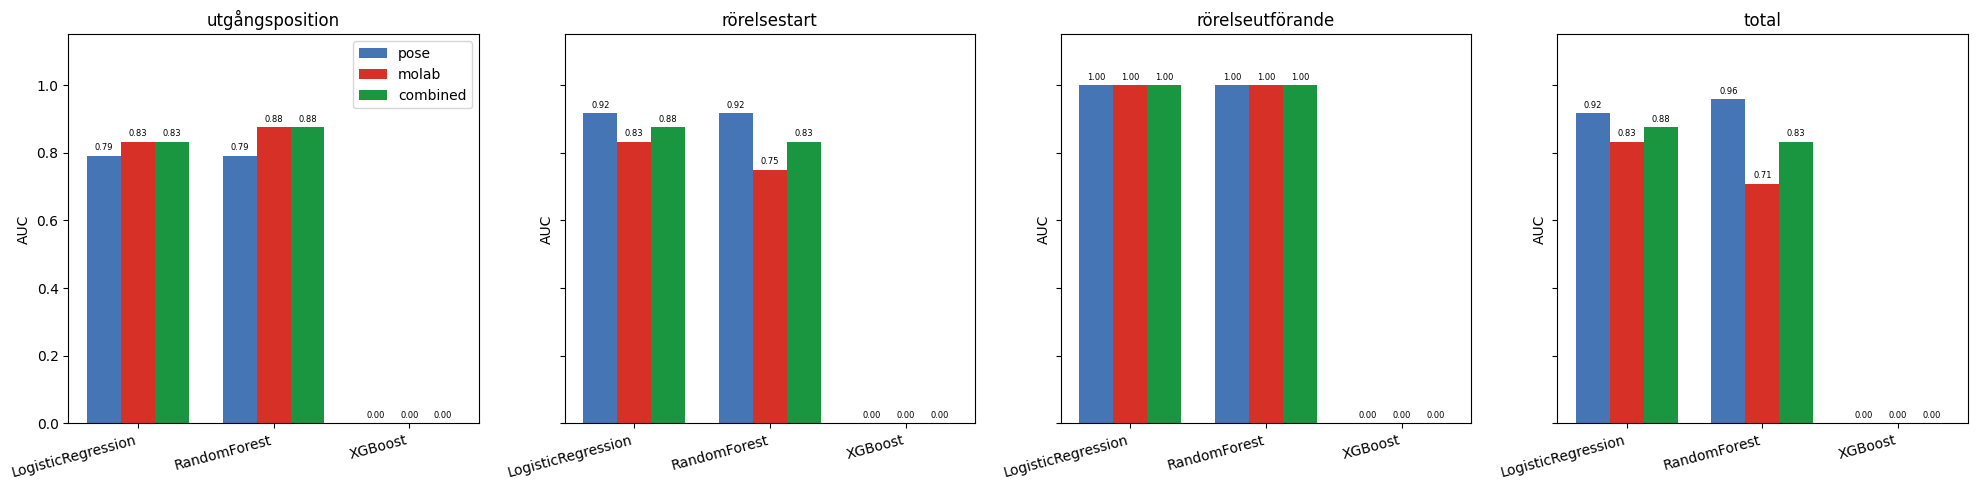

Saved: classification_auc_bar.png


In [68]:
COLORS = {'pose': '#4575b4', 'molab': '#d73027', 'combined': '#1a9641'}
PHASE_ORDER = ['utgångsposition', 'rörelsestart', 'rörelseutförande', 'total']

for metric in ['Accuracy', 'F1', 'AUC']:
    fig, axes = plt.subplots(1, len(PHASE_ORDER), figsize=(20, 5), sharey=True)
    for ax, phase in zip(axes, PHASE_ORDER):
        sub = eval_df[eval_df['phase'] == phase]
        x = np.arange(len(MODEL_ORDER))
        width = 0.25
        for i, fs in enumerate(FEATURE_SETS):
            vals = []
            for m in MODEL_ORDER:
                mask = (sub['model'] == m) & (sub['feature_set'] == fs)
                v    = sub[mask][metric].values
                vals.append(v[0] if len(v) else np.nan)
            bars = ax.bar(x + i * width, vals, width, label=fs, color=COLORS[fs])
            for bar, val in zip(bars, vals):
                if not np.isnan(val):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.01,
                        f'{val:.2f}',
                        ha='center', va='bottom', fontsize=6
                    )
        ax.set_title(phase)
        ax.set_xticks(x + width)
        ax.set_xticklabels(MODEL_ORDER, rotation=15, ha='right')
        ax.set_ylim(0, 1.15)
        ax.set_ylabel(metric)
    axes[0].legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'classification_{metric.lower()}_bar.png', dpi=150)
    plt.show()
    print(f'Saved: classification_{metric.lower()}_bar.png')


The bar charts confirm the pattern from the tables:

- **Rörelseutförande** shows the highest bars across all metrics. LR and RF reach perfect scores, XGBoost clearly falls behind.

- **Rörelsestart and Total**: LR and RF perform similarly, and Pose features perform as well as or better than Combined features.

- **Utgångsposition**: all models cluster around **0.7–0.8**, with no single model clearly dominating.

- **XGBoost** shows consistently low AUC bars after the fix, reflecting that it is too complex for this dataset size (n=10).

Overall, **Logistic Regression is the most reliable classifier across all phases and feature sets**.


## Champion model per phase

In [69]:
METRICS = ['Accuracy', 'F1', 'AUC']

champion_rows = []
for phase in eval_df['phase'].unique():
    for fs in FEATURE_SETS:
        sub  = eval_df[(eval_df['phase'] == phase) & (eval_df['feature_set'] == fs)]
        # Fall back to Accuracy if AUC is all NaN
        if sub['AUC'].notna().any():
            best = sub.loc[sub['AUC'].idxmax()]
        else:
            best = sub.loc[sub['Accuracy'].idxmax()]
        champion_rows.append({
            'phase':       phase,
            'feature_set': fs,
            'model':       best['model'],
            'Accuracy':    round(best['Accuracy'], 3),
            'F1':          round(best['F1'],       3),
            'AUC':         round(best['AUC'], 3) if pd.notna(best['AUC']) else float('nan'),
        })

champion_df = pd.DataFrame(champion_rows)
champion_df.to_csv(OUT_DIR / 'champion_models.csv', index=False)
print(champion_df.to_string(index=False))


           phase feature_set              model  Accuracy    F1   AUC
 utgångsposition        pose LogisticRegression       0.7 0.769 0.792
 utgångsposition       molab       RandomForest       0.8 0.833 0.875
 utgångsposition    combined       RandomForest       0.8 0.833 0.875
    rörelsestart        pose LogisticRegression       0.9 0.909 0.917
    rörelsestart       molab LogisticRegression       0.8 0.833 0.833
    rörelsestart    combined LogisticRegression       0.9 0.909 0.875
rörelseutförande        pose LogisticRegression       1.0 1.000 1.000
rörelseutförande       molab LogisticRegression       1.0 1.000 1.000
rörelseutförande    combined LogisticRegression       1.0 1.000 1.000
           total        pose       RandomForest       0.8 0.833 0.958
           total       molab LogisticRegression       0.7 0.769 0.833
           total    combined LogisticRegression       0.9 0.909 0.875


**Logistic Regression is the champion in 9 out of 12 combinations**.

## Per-video error comparison: Pose vs MoLab

In [70]:
rows = []
for r in loocv_results:
    for vid, yt, yp in zip(r['videos'], r['y_true'], r['y_pred']):
        rows.append({
            'phase':       r['phase'],
            'model':       r['model'],
            'feature_set': r['feature_set'],
            'video':       vid,
            'y_true':      yt,
            'y_pred':      yp,
        })

per_video_df = pd.DataFrame(rows)
per_video_df.to_csv(OUT_DIR / 'per_video_predictions.csv', index=False)

for phase in eval_df['phase'].unique():
    print(f"\n{'='*65}")
    print(f" Phase: {phase}")
    print(f"{'='*65}")
    for model in MODEL_ORDER:
        sub   = per_video_df[(per_video_df['phase'] == phase) & (per_video_df['model'] == model)]
        pose  = sub[sub['feature_set'] == 'pose'].set_index('video')[['y_true','y_pred']].rename(columns={'y_pred':'pose_pred'})
        molab = sub[sub['feature_set'] == 'molab'][['video','y_pred']].set_index('video').rename(columns={'y_pred':'molab_pred'})

        compare = pose.join(molab)
        compare['pose_error']  = compare['y_true'] != compare['pose_pred']
        compare['molab_error'] = compare['y_true'] != compare['molab_pred']

        diff = compare[compare['pose_error'] != compare['molab_error']]
        if diff.empty:
            continue

        print(f"\n  Model: {model}")
        print(f"  {'-'*55}")
        print(f"  {'Video':<8} {'True':>6} {'Pose':>8} {'MoLab':>8} {'Pose err':>10} {'MoLab err':>10}")
        print(f"  {'-'*55}")
        for vid, row in diff.iterrows():
            pose_err  = 'FP' if (row.pose_error  and row.pose_pred  > row.y_true) else ('FN' if row.pose_error  else '-')
            molab_err = 'FP' if (row.molab_error and row.molab_pred > row.y_true) else ('FN' if row.molab_error else '-')
            print(f"  {str(vid):<8} {int(row.y_true):>6} {int(row.pose_pred):>8} {int(row.molab_pred):>8} {pose_err:>10} {molab_err:>10}")
        print(f"  {'-'*55}")



 Phase: utgångsposition

  Model: LogisticRegression
  -------------------------------------------------------
  Video      True     Pose    MoLab   Pose err  MoLab err
  -------------------------------------------------------
  093           0        1        0         FP          -
  -------------------------------------------------------

  Model: RandomForest
  -------------------------------------------------------
  Video      True     Pose    MoLab   Pose err  MoLab err
  -------------------------------------------------------
  030           0        0        1          -         FP
  093           0        1        0         FP          -
  -------------------------------------------------------

 Phase: rörelsestart

  Model: LogisticRegression
  -------------------------------------------------------
  Video      True     Pose    MoLab   Pose err  MoLab err
  -------------------------------------------------------
  061           0        0        1          -         FP
  

- **MoLab over-predicts deviation**: most errors are False Positives (predicted 1, true 0) in videos 030, 047, 061, 076.
- **Pose is more precise**: only one FP (video 093) and one FN (video 091).
- MoLab is sensitive but flags too many healthy cases as deviations.


## Stående till sittande (Stand-to-Sit)

In [71]:
OUT_DIR_DOWN_CLS = Path('../data/processed/classification_down')
OUT_DIR_DOWN_CLS.mkdir(parents=True, exist_ok=True)

DOWN_FEATURES_DIR_CLS = Path('../data/processed/features_down')
DOWN_SELECTED_DIR_CLS = DOWN_FEATURES_DIR_CLS / 'combined/per_video'

PHASE_MAP_DOWN_CLS = {
    'iraf_utgångsposition':  'selected_features_init.csv',
    'iraf_rörelsestart':     'selected_features_start.csv',
    'iraf_rörelseutförande': 'selected_features_execution.csv',
    'iraf_total':            'selected_features_total.csv',
}

RAK_DOWN_FP_VIDEOS_CLS = ['030', '047', '061', '076', '093']

kors_df_d, kors_pw_d = parse_iraf_per_video(kors_xl, 'Stående till sittande')
rak_df_d,  rak_pw_d  = parse_iraf_per_video(rak_xl,  'Stående till sittande', fp_videos=RAK_DOWN_FP_VIDEOS_CLS)
iraf_raw_d = pd.concat([kors_df_d, rak_df_d], ignore_index=True)
iraf_raw_d = iraf_raw_d.assign(w=iraf_raw_d['avvikelse'] * iraf_raw_d['weight'])

phase_weights_d = pd.concat([kors_pw_d, rak_pw_d]).groupby('phase')['phase_weight'].mean().to_dict()

iraf_pv_d = iraf_raw_d.groupby(['video', 'phase']).apply(
    lambda g: g['w'].sum() / g['weight'].sum()
).unstack().reset_index()
iraf_pv_d.columns.name = None
iraf_pv_d.columns = ['video'] + [f'iraf_{c}' for c in iraf_pv_d.columns[1:]]

total_w_d = sum(phase_weights_d.values())
iraf_pv_d['iraf_total'] = sum(iraf_pv_d[f'iraf_{p}'] * w for p, w in phase_weights_d.items()) / total_w_d

iraf_bin_d = iraf_pv_d.copy()
for col in [c for c in iraf_bin_d.columns if c.startswith('iraf_')]:
    iraf_bin_d[col] = iraf_bin_d[col].apply(to_binary)
iraf_bin_d['video'] = iraf_bin_d['video'].astype(str).str.zfill(3)

iraf_bin_d


,video,iraf_rörelsestart,iraf_rörelseutförande,iraf_utgångsposition,iraf_total
0,028,0,0,0,0.0
1,030,0,0,0,0.0
2,045,1,1,1,1.0
3,047,0,0,0,0.0
4,059,0,0,0,0.0
5,061,0,0,0,0.0
6,074,1,1,1,1.0
7,076,1,1,1,1.0
8,091,0,1,1,0.0
9,093,0,0,1,NaN


In [72]:
pose_all_d = (
    pd.read_csv(DOWN_FEATURES_DIR_CLS / 'down_utgångsposition.csv')
    .merge(pd.read_csv(DOWN_FEATURES_DIR_CLS / 'down_rörelsestart.csv'),     on='video')
    .merge(pd.read_csv(DOWN_FEATURES_DIR_CLS / 'down_rörelseutförande.csv'), on='video')
)
molab_all_d = (
    pd.read_csv(DOWN_FEATURES_DIR_CLS / 'down_molab_utgångsposition.csv')
    .merge(pd.read_csv(DOWN_FEATURES_DIR_CLS / 'down_molab_rörelsestart.csv'),     on='video')
    .merge(pd.read_csv(DOWN_FEATURES_DIR_CLS / 'down_molab_rörelseutförande.csv'), on='video')
)

pose_all_d['video']  = pose_all_d['video'].astype(str).str.zfill(3)
molab_all_d['video'] = molab_all_d['video'].astype(str).str.zfill(3)
pose_all_d  = pose_all_d.rename(columns={c: f'pose_{c}'  for c in pose_all_d.columns  if c != 'video'})
molab_all_d = molab_all_d.rename(columns={c: f'molab_{c}' for c in molab_all_d.columns if c != 'video'})

phase_dfs_down_cls = {}
for target, fname in PHASE_MAP_DOWN_CLS.items():
    sel = pd.read_csv(DOWN_SELECTED_DIR_CLS / fname)
    pose_feats  = [f'pose_{f}'  for f in sel[sel['source'] == 'Pose']['feature'].tolist()]
    molab_feats = [f'molab_{f}' for f in sel[sel['source'] == 'MoLab']['feature'].tolist()]
    short = target.replace('iraf_', '')

    y_df = iraf_bin_d[['video', target]].dropna()

    pose_df  = pose_all_d[['video'] + pose_feats].merge(y_df[['video']], on='video')
    molab_df = molab_all_d[['video'] + molab_feats].merge(y_df[['video']], on='video')

    phase_dfs_down_cls[short] = {
        'pose':     pose_df,
        'molab':    molab_df,
        'combined': pose_df.merge(molab_df, on='video'),
        'y':        y_df,
    }

for phase, sources in phase_dfs_down_cls.items():
    print(f"\n{phase}: n={len(sources['y'])}, labels={sources['y'].iloc[:,1].value_counts().to_dict()}")



utgångsposition: n=10, labels={0: 5, 1: 5}

rörelsestart: n=10, labels={0: 7, 1: 3}

rörelseutförande: n=10, labels={0: 6, 1: 4}

total: n=9, labels={0.0: 6, 1.0: 3}


In [73]:
loocv_results_down_cls = []

for phase, data in phase_dfs_down_cls.items():
    target  = 'iraf_' + phase
    y_df    = data['y']
    videos_d  = y_df['video'].values
    y_all   = y_df[target].values.astype(int)
    for fs in FEATURE_SETS:
        merged = data[fs].merge(y_df[['video']], on='video')
        X      = merged.drop(columns='video').values
        for model_name, model in MODELS.items():
            y_true, y_pred, y_prob, vid_out = [], [], [], []
            for train_idx, test_idx in loo.split(X):
                X_train, X_test = X[train_idx], X[test_idx]
                y_train = y_all[train_idx]
                if len(np.unique(y_train)) < 2:
                    continue
                scaler  = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test  = scaler.transform(X_test)
                m = clone(model)
                m.fit(X_train, y_train)
                y_true.append(y_all[test_idx][0])
                y_pred.append(m.predict(X_test)[0])
                prob    = m.predict_proba(X_test)[0]
                pos_idx = list(m.classes_).index(1) if 1 in m.classes_ else 0
                y_prob.append(prob[pos_idx])
                vid_out.append(videos_d[test_idx][0])
            loocv_results_down_cls.append({
                'phase':       phase,
                'model':       model_name,
                'feature_set': fs,
                'videos':      vid_out,
                'y_true':      y_true,
                'y_pred':      y_pred,
                'y_prob':      y_prob,
            })

print(f'Completed: {len(loocv_results_down_cls)} models trained')


Completed: 36 models trained


In [74]:
rows_d = []
for r in loocv_results_down_cls:
    yt, yp, ypr = r['y_true'], r['y_pred'], r['y_prob']
    n_classes = len(set(yt))
    rows_d.append({
        'phase':       r['phase'],
        'model':       r['model'],
        'feature_set': r['feature_set'],
        'Accuracy':    accuracy_score(yt, yp),
        'F1':          f1_score(yt, yp, zero_division=0),
        'Precision':   precision_score(yt, yp, zero_division=0),
        'Recall':      recall_score(yt, yp, zero_division=0),
        'AUC':         roc_auc_score(yt, ypr) if n_classes > 1 else np.nan,
    })

eval_df_down_cls = pd.DataFrame(rows_d)
eval_df_down_cls.to_csv(OUT_DIR_DOWN_CLS / 'classification_results.csv', index=False)

METRICS_D = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC']

for phase in eval_df_down_cls['phase'].unique():
    print(f"\nPhase: {phase}")
    sub   = eval_df_down_cls[eval_df_down_cls['phase'] == phase].copy()
    table = sub.pivot_table(index='model', columns='feature_set', values=METRICS_D).round(3)
    table.columns = [f'{metric}_{fs}' for metric, fs in table.columns]
    print(table.to_string())
    print()



Phase: utgångsposition
                    AUC_combined  AUC_molab  AUC_pose  Accuracy_combined  Accuracy_molab  Accuracy_pose  F1_combined  F1_molab  F1_pose  Precision_combined  Precision_molab  Precision_pose  Recall_combined  Recall_molab  Recall_pose
model                                                                                                                                                                                                                                   
LogisticRegression          0.88       0.76       1.0                0.9             0.8            0.9        0.909       0.8    0.889               0.833              0.8           1.000              1.0           0.8          0.8
RandomForest                1.00       0.72       1.0                1.0             0.8            0.9        1.000       0.8    0.909               1.000              0.8           0.833              1.0           0.8          1.0
XGBoost                     0.00       0.00 

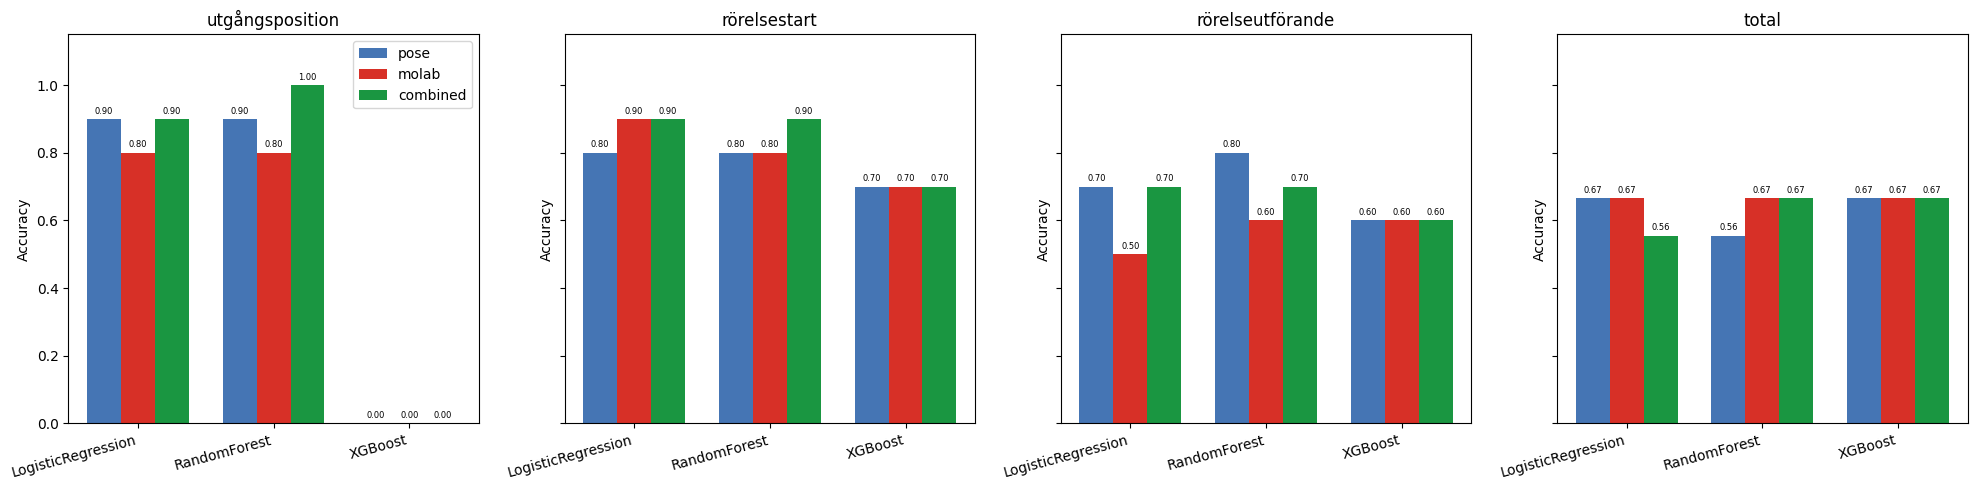

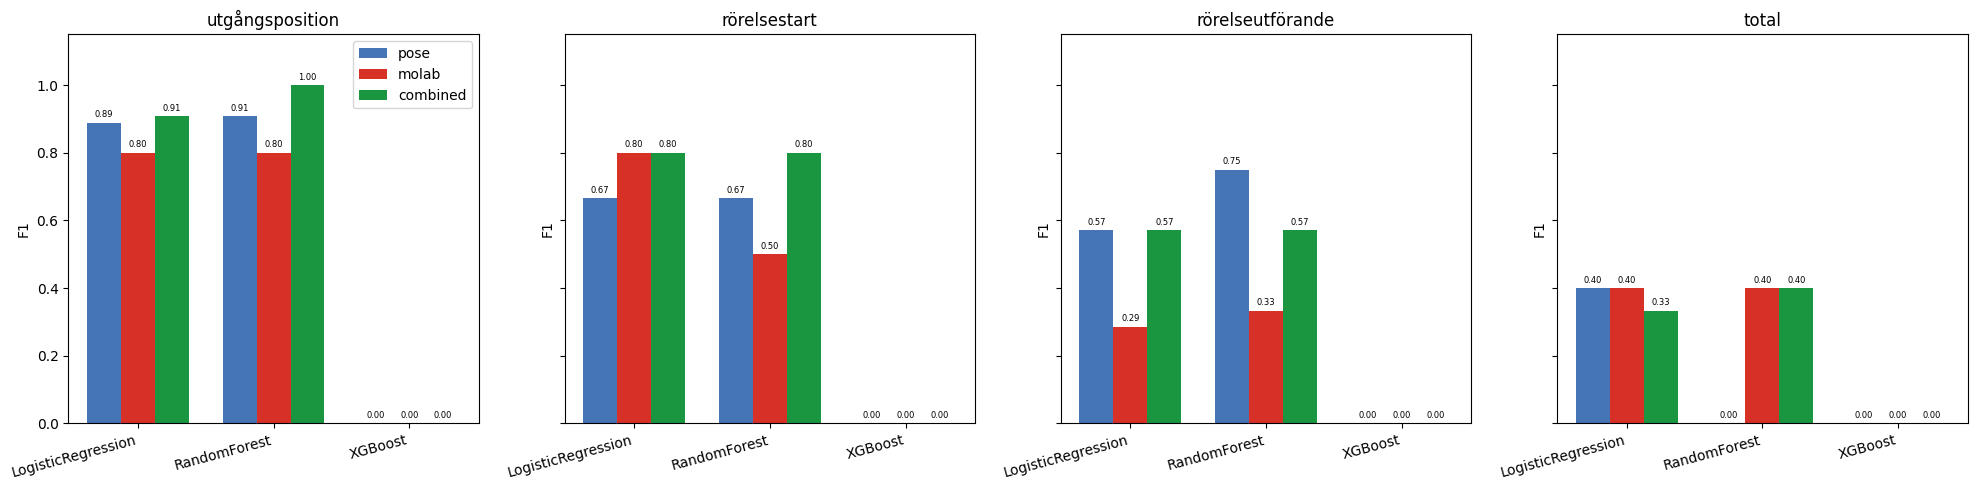

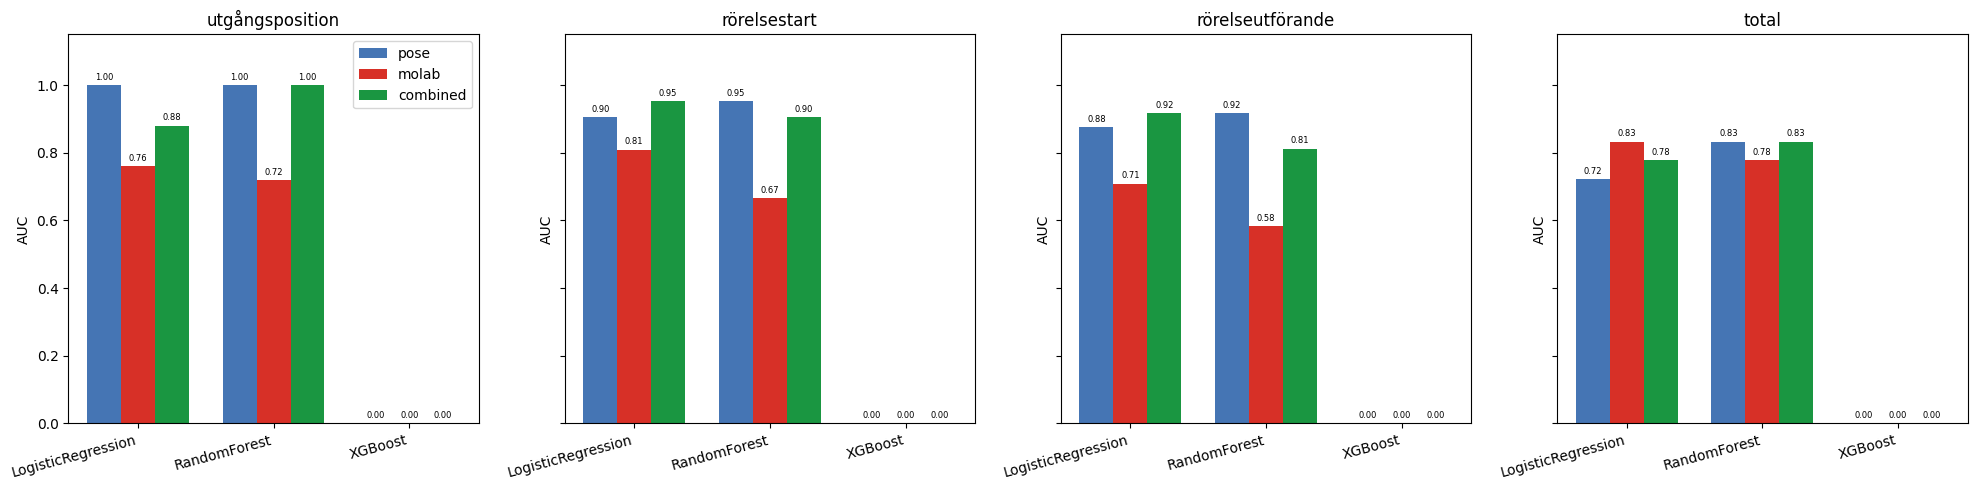

In [75]:
COLORS_D = {'pose': '#4575b4', 'molab': '#d73027', 'combined': '#1a9641'}
PHASE_ORDER_DOWN_CLS = list(phase_dfs_down_cls.keys())

for metric in ['Accuracy', 'F1', 'AUC']:
    fig, axes = plt.subplots(1, len(PHASE_ORDER_DOWN_CLS), figsize=(20, 5), sharey=True)
    for ax, phase in zip(axes, PHASE_ORDER_DOWN_CLS):
        sub = eval_df_down_cls[eval_df_down_cls['phase'] == phase]
        x = np.arange(len(MODEL_ORDER))
        width = 0.25
        for i, fs in enumerate(FEATURE_SETS):
            vals = []
            for m in MODEL_ORDER:
                mask = (sub['model'] == m) & (sub['feature_set'] == fs)
                v    = sub[mask][metric].values
                vals.append(v[0] if len(v) else np.nan)
            bars = ax.bar(x + i * width, vals, width, label=fs, color=COLORS_D[fs])
            for bar, val in zip(bars, vals):
                if not np.isnan(val):
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                            f'{val:.2f}', ha='center', va='bottom', fontsize=6)
        ax.set_title(phase)
        ax.set_xticks(x + width)
        ax.set_xticklabels(MODEL_ORDER, rotation=15, ha='right')
        ax.set_ylim(0, 1.15)
        ax.set_ylabel(metric)
    axes[0].legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR_DOWN_CLS / f'classification_{metric.lower()}_bar.png', dpi=150)
    plt.show()


In [76]:
mcnemar_rows_d = []

model_pairs = [
    ('LogisticRegression', 'RandomForest'),
    ('LogisticRegression', 'XGBoost'),
    ('RandomForest',       'XGBoost'),
]

for phase in eval_df_down_cls['phase'].unique():
    for fs in FEATURE_SETS:
        for m1, m2 in model_pairs:
            r1 = next(r for r in loocv_results_down_cls
                      if r['phase'] == phase and r['model'] == m1 and r['feature_set'] == fs)
            r2 = next(r for r in loocv_results_down_cls
                      if r['phase'] == phase and r['model'] == m2 and r['feature_set'] == fs)
            yt = np.array(r1['y_true'])
            p1 = np.array(r1['y_pred'])
            p2 = np.array(r2['y_pred'])
            b = np.sum((p1 == yt) & (p2 != yt))
            c = np.sum((p1 != yt) & (p2 == yt))
            table = [[np.sum((p1 == yt) & (p2 == yt)), b],
                     [c, np.sum((p1 != yt) & (p2 != yt))]]
            result = mcnemar(table, exact=True)
            mcnemar_rows_d.append({
                'phase':       phase,
                'feature_set': fs,
                'model_1':     m1,
                'model_2':     m2,
                'b':           b,
                'c':           c,
                'p_value':     result.pvalue,
                'significant': result.pvalue < 0.05,
            })

mcnemar_df_d = pd.DataFrame(mcnemar_rows_d)
mcnemar_df_d.to_csv(OUT_DIR_DOWN_CLS / 'mcnemar_results.csv', index=False)

print(mcnemar_df_d[['phase','feature_set','model_1','model_2','p_value','significant']].to_string(index=False))


           phase feature_set            model_1      model_2  p_value  significant
 utgångsposition        pose LogisticRegression RandomForest 1.000000        False
 utgångsposition        pose LogisticRegression      XGBoost 0.003906         True
 utgångsposition        pose       RandomForest      XGBoost 0.003906         True
 utgångsposition       molab LogisticRegression RandomForest 1.000000        False
 utgångsposition       molab LogisticRegression      XGBoost 0.007812         True
 utgångsposition       molab       RandomForest      XGBoost 0.007812         True
 utgångsposition    combined LogisticRegression RandomForest 1.000000        False
 utgångsposition    combined LogisticRegression      XGBoost 0.003906         True
 utgångsposition    combined       RandomForest      XGBoost 0.001953         True
    rörelsestart        pose LogisticRegression RandomForest 1.000000        False
    rörelsestart        pose LogisticRegression      XGBoost 1.000000        False
    

In [77]:
rows_pv_d = []
for r in loocv_results_down_cls:
    for vid, yt, yp in zip(r['videos'], r['y_true'], r['y_pred']):
        rows_pv_d.append({
            'phase':       r['phase'],
            'model':       r['model'],
            'feature_set': r['feature_set'],
            'video':       vid,
            'y_true':      yt,
            'y_pred':      yp,
        })

per_video_df_d = pd.DataFrame(rows_pv_d)
per_video_df_d.to_csv(OUT_DIR_DOWN_CLS / 'per_video_predictions.csv', index=False)

for phase in eval_df_down_cls['phase'].unique():
    print(f"\n{'='*65}")
    print(f" Phase: {phase}")
    print(f"{'='*65}")
    for model in MODEL_ORDER:
        sub   = per_video_df_d[(per_video_df_d['phase'] == phase) & (per_video_df_d['model'] == model)]
        pose  = sub[sub['feature_set'] == 'pose'].set_index('video')[['y_true','y_pred']].rename(columns={'y_pred':'pose_pred'})
        molab = sub[sub['feature_set'] == 'molab'][['video','y_pred']].set_index('video').rename(columns={'y_pred':'molab_pred'})

        compare = pose.join(molab)
        compare['pose_error']  = compare['y_true'] != compare['pose_pred']
        compare['molab_error'] = compare['y_true'] != compare['molab_pred']

        diff = compare[compare['pose_error'] != compare['molab_error']]
        if diff.empty:
            continue

        print(f"\n  Model: {model}")
        print(f"  {'-'*55}")
        print(f"  {'Video':<8} {'True':>6} {'Pose':>8} {'MoLab':>8} {'Pose err':>10} {'MoLab err':>10}")
        print(f"  {'-'*55}")
        for vid, row in diff.iterrows():
            pose_err  = 'FP' if (row.pose_error  and row.pose_pred  > row.y_true) else ('FN' if row.pose_error  else '-')
            molab_err = 'FP' if (row.molab_error and row.molab_pred > row.y_true) else ('FN' if row.molab_error else '-')
            print(f"  {str(vid):<8} {int(row.y_true):>6} {int(row.pose_pred):>8} {int(row.molab_pred):>8} {pose_err:>10} {molab_err:>10}")
        print(f"  {'-'*55}")



 Phase: utgångsposition

  Model: LogisticRegression
  -------------------------------------------------------
  Video      True     Pose    MoLab   Pose err  MoLab err
  -------------------------------------------------------
  047           0        0        1          -         FP
  074           1        1        0          -         FN
  076           1        0        1         FN          -
  -------------------------------------------------------

  Model: RandomForest
  -------------------------------------------------------
  Video      True     Pose    MoLab   Pose err  MoLab err
  -------------------------------------------------------
  047           0        0        1          -         FP
  059           0        1        0         FP          -
  074           1        1        0          -         FN
  -------------------------------------------------------

 Phase: rörelsestart

  Model: LogisticRegression
  -------------------------------------------------------
  

In [78]:
champion_rows_d = []
for phase in eval_df_down_cls['phase'].unique():
    for fs in FEATURE_SETS:
        sub  = eval_df_down_cls[(eval_df_down_cls['phase'] == phase) & (eval_df_down_cls['feature_set'] == fs)]
        if sub['AUC'].notna().any():
            best = sub.loc[sub['AUC'].idxmax()]
        else:
            best = sub.loc[sub['Accuracy'].idxmax()]
        champion_rows_d.append({
            'phase':       phase,
            'feature_set': fs,
            'model':       best['model'],
            'Accuracy':    round(best['Accuracy'], 3),
            'F1':          round(best['F1'],       3),
            'AUC':         round(best['AUC'], 3) if pd.notna(best['AUC']) else float('nan'),
        })

champion_df_down = pd.DataFrame(champion_rows_d)
champion_df_down.to_csv(OUT_DIR_DOWN_CLS / 'champion_models.csv', index=False)
print(champion_df_down.to_string(index=False))


           phase feature_set              model  Accuracy    F1   AUC
 utgångsposition        pose LogisticRegression     0.900 0.889 1.000
 utgångsposition       molab LogisticRegression     0.800 0.800 0.760
 utgångsposition    combined       RandomForest     1.000 1.000 1.000
    rörelsestart        pose       RandomForest     0.800 0.667 0.952
    rörelsestart       molab LogisticRegression     0.900 0.800 0.810
    rörelsestart    combined LogisticRegression     0.900 0.800 0.952
rörelseutförande        pose       RandomForest     0.800 0.750 0.917
rörelseutförande       molab LogisticRegression     0.500 0.286 0.708
rörelseutförande    combined LogisticRegression     0.700 0.571 0.917
           total        pose       RandomForest     0.556 0.000 0.833
           total       molab LogisticRegression     0.667 0.400 0.833
           total    combined       RandomForest     0.667 0.400 0.833
